In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

df = yf.download("AAPL", start="2015-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_2003/3263493799.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.171761,24.638260,23.734002,24.627205,212818400
2015-01-05,23.490797,24.021413,23.305082,23.941821,257142000
2015-01-06,23.493008,23.751682,23.132630,23.554913,263188400
2015-01-07,23.822432,23.921921,23.590287,23.700831,160423600
2015-01-08,24.737749,24.795233,24.032472,24.149651,237458000


In [ ]:
df.to_csv("AAPL.csv")

In [ ]:
import pandas as pd      # to load dataset
import numpy as np       # for mathematical operations
import matplotlib.pyplot as plt   # for visualization

from sklearn.preprocessing import MinMaxScaler   # normalize dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential   # the model
from tensorflow.keras.layers import LSTM, Dense, Dropout   # layers of architecture
from tensorflow.keras.callbacks import ModelCheckpoint     # save model
from tensorflow.keras.models import load_model             # load saved model

In [ ]:
data = pd.read_csv('AAPL.csv')

print(data)

           Price               Close                High                 Low  \
0         Ticker                AAPL                AAPL                AAPL   
1           Date                 NaN                 NaN                 NaN   
2     2015-01-02   24.17176055908203  24.638260409797738  23.734001789774272   
3     2015-01-05   23.49079704284668   24.02141303105321  23.305082374704345   
4     2015-01-06   23.49300765991211   23.75168237657432  23.132630129065518   
...          ...                 ...                 ...                 ...   
2513  2024-12-24  256.33978271484375  256.34969006633503   253.4507293352449   
2514  2024-12-26     257.15380859375   258.2260444048055  255.77383898408218   
2515  2024-12-27     253.74853515625    256.836144148833   251.2367643772991   
2516  2024-12-30  250.38294982910156  251.67358663649517  248.94339979921563   
2517  2024-12-31  248.61578369140625  251.45517870098834  247.63291094425557   

                    Open     Volume  
0

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2518 non-null   object
 1   Close   2517 non-null   object
 2   High    2517 non-null   object
 3   Low     2517 non-null   object
 4   Open    2517 non-null   object
 5   Volume  2517 non-null   object
dtypes: object(6)
memory usage: 118.2+ KB
None


In [ ]:
print(data.isnull().sum())

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


TypeError: 'value' must be an instance of str or bytes, not a float

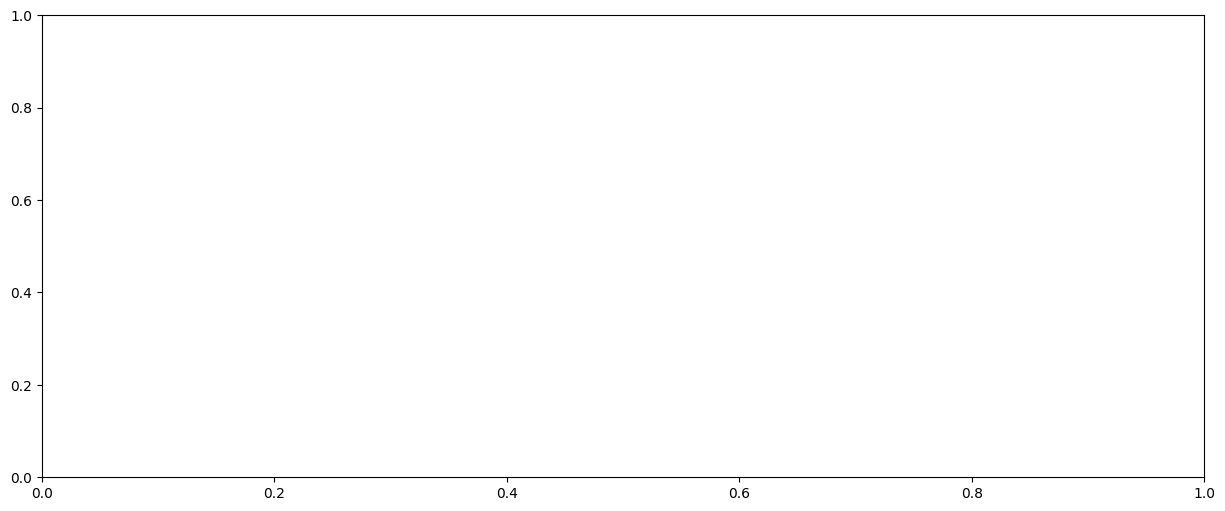

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(data['Close'])

plt.title('Apple Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [ ]:
print(data.columns)

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [ ]:
data.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,24.17176055908203,24.638260409797738,23.734001789774272,24.627205239450436,212818400
3,2015-01-05,23.49079704284668,24.02141303105321,23.305082374704345,23.941820548483143,257142000
4,2015-01-06,23.49300765991211,23.75168237657432,23.132630129065518,23.554912547306653,263188400


In [ ]:
print(type(data['Close']))

<class 'pandas.core.series.Series'>


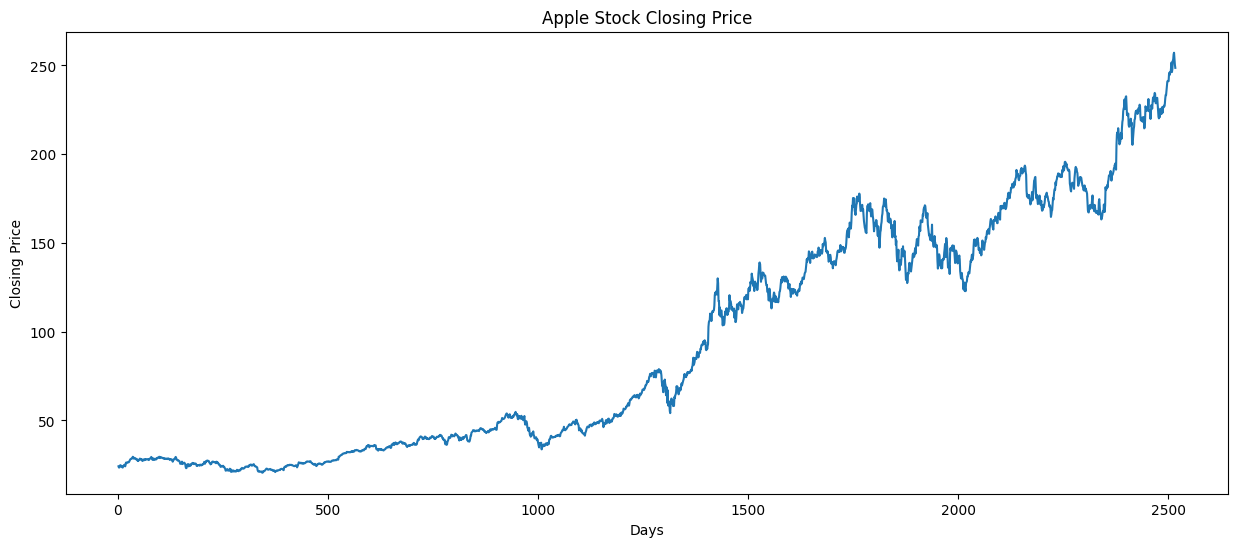

In [ ]:
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

plt.figure(figsize=(15,6))
plt.plot(data['Close'].values)
plt.title("Apple Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.show()

In [ ]:
stock_data = data[['Close']]

print(stock_data.head())

       Close
0        NaN
1        NaN
2  24.171761
3  23.490797
4  23.493008


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(stock_data)

print(scaled_data[:5])

[[       nan]
 [       nan]
 [0.01531499]
 [0.01243694]
 [0.01244628]]


In [ ]:
training_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:training_size]
test_data = scaled_data[training_size-60:]

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)

Training Data Shape: (2014, 1)
Testing Data Shape: (564, 1)


In [ ]:
def create_dataset(dataset):

    x = []
    y = []

    for i in range(60, len(dataset)):
        x.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])

    return np.array(x), np.array(y)

In [ ]:
x_train, y_train = create_dataset(train_data)
x_test, y_test = create_dataset(test_data)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(1954, 60)
(1954,)
(504, 60)
(504,)


In [ ]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

print(x_train.shape)
print(x_test.shape)

(1954, 60, 1)
(504, 60, 1)


In [ ]:
# Build LSTM Model

model = Sequential()

# First LSTM Layer
model.add(LSTM(units=50,
               return_sequences=True,
               input_shape=(x_train.shape[1], 1)))

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=50))

model.add(Dropout(0.2))

# Output Layer
model.add(Dense(units=1))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
checkpoint = ModelCheckpoint(
    "stock_lstm.keras",
    monitor="loss",
    save_best_only=True,
    verbose=1
)

In [ ]:
print(data.isnull().sum())

Price     0
Close     2
High      1
Low       1
Open      1
Volume    1
dtype: int64


In [ ]:
print(stock_data.isnull().sum())

Close    2
dtype: int64


In [ ]:
# Keep only required columns
stock_data = data[['Close']].copy()

# Convert to numeric
stock_data['Close'] = pd.to_numeric(stock_data['Close'], errors='coerce')

# Remove missing values
stock_data.dropna(inplace=True)

# Reset index
stock_data.reset_index(drop=True, inplace=True)

print(stock_data.isnull().sum())
print(stock_data.head())

Close    0
dtype: int64
       Close
0  24.171761
1  23.490797
2  23.493008
3  23.822432
4  24.737749


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(stock_data)

print(np.isnan(scaled_data).sum())

0


In [ ]:
training_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:training_size]
test_data = scaled_data[training_size-60:]

In [ ]:
x_train, y_train = create_dataset(train_data)
x_test, y_test = create_dataset(test_data)

In [ ]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

In [ ]:
model = Sequential()

model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(x_train.shape[1], 1)
))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint = ModelCheckpoint(
    "stock_lstm.keras",
    monitor="loss",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[checkpoint]
)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0220
Epoch 1: loss improved from None to 0.00849, saving model to stock_lstm.keras

Epoch 1: finished saving model to stock_lstm.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0085 - val_loss: 0.0021
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0011
Epoch 2: loss improved from 0.00849 to 0.00114, saving model to stock_lstm.keras

Epoch 2: finished saving model to stock_lstm.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0011 - val_loss: 9.1244e-04
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0011
Epoch 3: loss improved from 0.00114 to 0.00113, saving model to stock_lstm.keras

Epoch 3: finished saving model to stock_lstm.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 4/10
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.8494e-04
Epoch 4: loss improved from 0.00113 to 0.00090, saving model to stock_lstm.keras

Epoch 4: finished saving mod

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("stock_lstm.keras")

In [ ]:
predictions = best_model.predict(x_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [ ]:
predictions = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [ ]:
result = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predictions.flatten()
})

result.head(10)

,Actual Price,Predicted Price
0,127.337135,134.174759
1,127.651482,133.067337
2,122.876740,132.102539
3,124.144127,131.082977
4,122.827621,130.124542
5,127.346962,129.194229
6,127.867661,128.520493
7,128.437454,128.088013
8,131.149078,127.880226
9,131.070465,127.964836


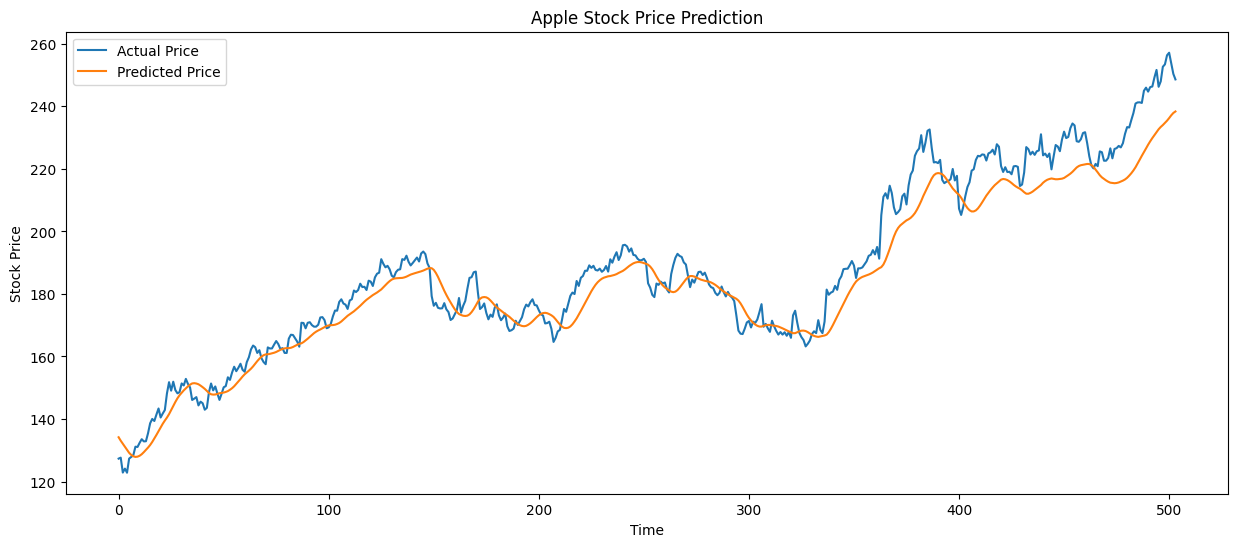

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.title("Apple Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

In [ ]:
mae = mean_absolute_error(actual_prices, predictions)
mse = mean_squared_error(actual_prices, predictions)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

MAE : 6.105683917091007
MSE : 61.92593998443366
RMSE : 7.869303653083522
